# 01 — Підготовка DEM
Обрізка та перевірка растру перед моделюванням.

In [54]:
import sys, pathlib
import numpy as np
import rasterio
import matplotlib.pyplot as plt

project_root = pathlib.Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.loader import load_dem


## Завантаження сирих даних та підготовка шляху збереження

In [55]:
import numpy as np
import pathlib
from src.loader import load_dem
from src.model import FloodModel

raw_path = pathlib.Path("../data/raw/OSNOVA.tif")

dem, profile, bounds = load_dem(str(raw_path))
model = FloodModel(dem)


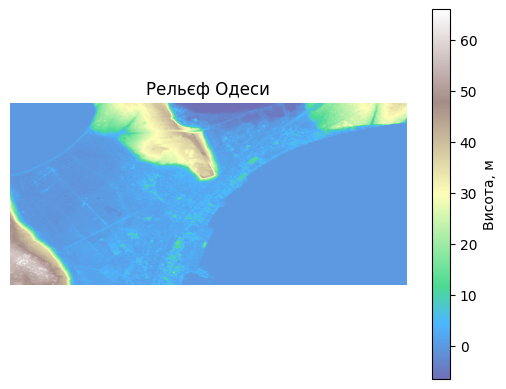

In [56]:
with rasterio.open(raw_path) as src:
    data = src.read(1)

plt.imshow(dem, cmap='terrain', alpha = 0.7)
plt.colorbar(label='Висота, м')
plt.title('Рельєф Одеси')
plt.axis('off')
plt.show()



## 1. Загальна інформація про DEM

In [57]:
print("=== DEM INFO ===")
print(f"Розмір растру: {dem.shape[0]} x {dem.shape[1]} пікселів")
print(f"Всього пікселів: {dem.size:,}")
print(f"NoData пікселів: {np.isnan(dem).sum():,}")
print(f"CRS: {profile['crs']}")


=== DEM INFO ===
Розмір растру: 200 x 435 пікселів
Всього пікселів: 87,000
NoData пікселів: 0
CRS: EPSG:4326


## 2. Просторова роздільність

In [58]:
transform = profile["transform"]
px_w = transform.a
px_h = -transform.e

print("\n=== PIXEL SIZE ===")
print(f"Розмір пікселя: {px_w:.6f} x {px_h:.6f} (в одиницях CRS)")

if profile["crs"].is_geographic:
    lat = (bounds.top + bounds.bottom) / 2
    px_w_m = px_w * 111_320 * np.cos(np.deg2rad(lat))
    px_h_m = px_h * 111_320
    print(f"Розмір пікселя ≈ {px_w_m:.1f} x {px_h_m:.1f} м")



=== PIXEL SIZE ===
Розмір пікселя: 0.000278 x 0.000278 (в одиницях CRS)
Розмір пікселя ≈ 21.3 x 30.9 м


## 3. Статистика висот

In [59]:
print("\n=== HEIGHT STATISTICS ===")
print(f"Мінімум: {np.nanmin(dem):.2f} м")
print(f"5-й персентиль: {np.nanpercentile(dem, 5):.2f} м")
print(f"10-й персентиль: {np.nanpercentile(dem, 10):.2f} м")
print(f"50-й персентиль: {np.nanpercentile(dem, 50):.2f} м")
print(f"70-й персентиль: {np.nanpercentile(dem, 70):.2f} м")

print(f"Медіана: {np.nanmedian(dem):.2f} м")
print(f"Середнє: {np.nanmean(dem):.2f} м")
print(f"Максимум: {np.nanmax(dem):.2f} м")



=== HEIGHT STATISTICS ===
Мінімум: -6.50 м
5-й персентиль: -0.80 м
10-й персентиль: -0.17 м
50-й персентиль: 0.00 м
70-й персентиль: 2.07 м
Медіана: 0.00 м
Середнє: 5.19 м
Максимум: 66.00 м


## 4. Калібрування моря

In [60]:
sea_bias = model.calibrate_sea_level()
base_flood = model.calculate_flood(sea_bias)

print("\n=== SEA CALIBRATION ===")
print(f"Sea bias (поточний рівень моря): {sea_bias:.3f} м")
print(f"Площа поточного моря: {base_flood.sum():,} пікселів")



=== SEA CALIBRATION ===
Sea bias (поточний рівень моря): 0.000 м
Площа поточного моря: 31,868 пікселів
